### **Statisctial Analysis on the Data**

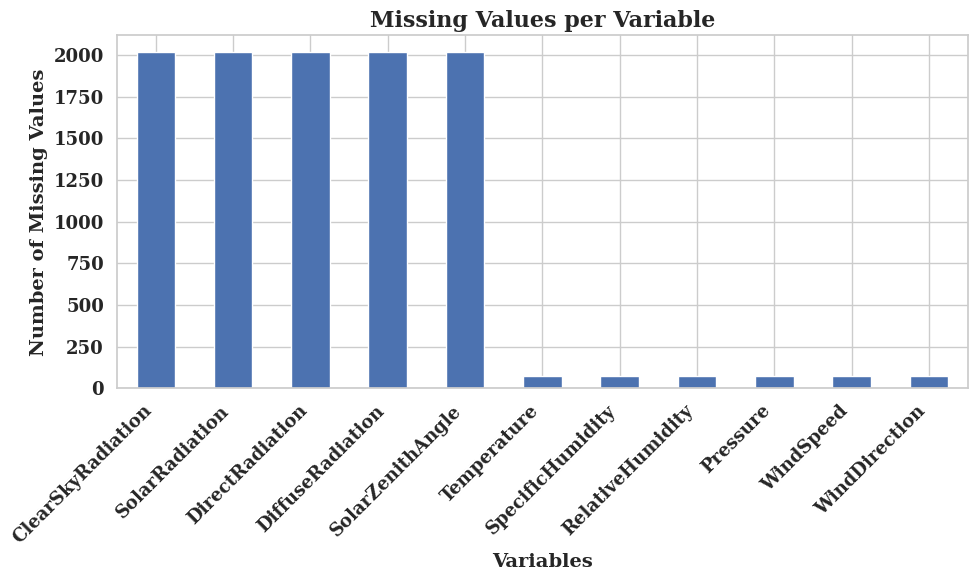

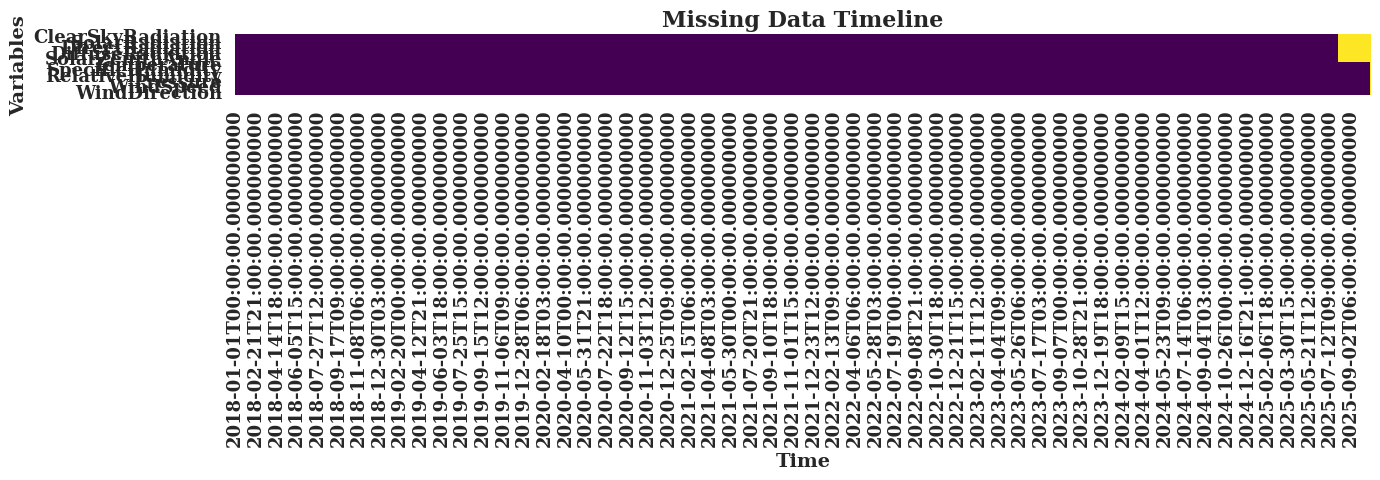


🔍 Checking missing values before fill:
ClearSkyRadiation    2016
SolarRadiation       2016
DirectRadiation      2016
DiffuseRadiation     2016
SolarZenithAngle     2016
Temperature            72
SpecificHumidity       72
RelativeHumidity       72
Pressure               72
WindSpeed              72
WindDirection          72
dtype: int64

✅ Missing values filled using climatology

📊 Basic Descriptive Statistics:
                     count        mean         std    min     25%     50%  \
ClearSkyRadiation  68448.0  231.955154  304.082804   0.00    0.00   11.12   
SolarRadiation     68448.0  200.427805  275.379165   0.00    0.00    9.52   
DirectRadiation    68448.0  158.136201  243.170856   0.00    0.00    0.00   
DiffuseRadiation   68448.0   90.976418  118.266235   0.00    0.00   11.26   
SolarZenithAngle   68448.0   72.461867   22.730187  10.59   56.19   88.07   
Temperature        68448.0   25.099201    9.608141   0.32   17.76   26.23   
SpecificHumidity   68448.0   10.492169    5.98

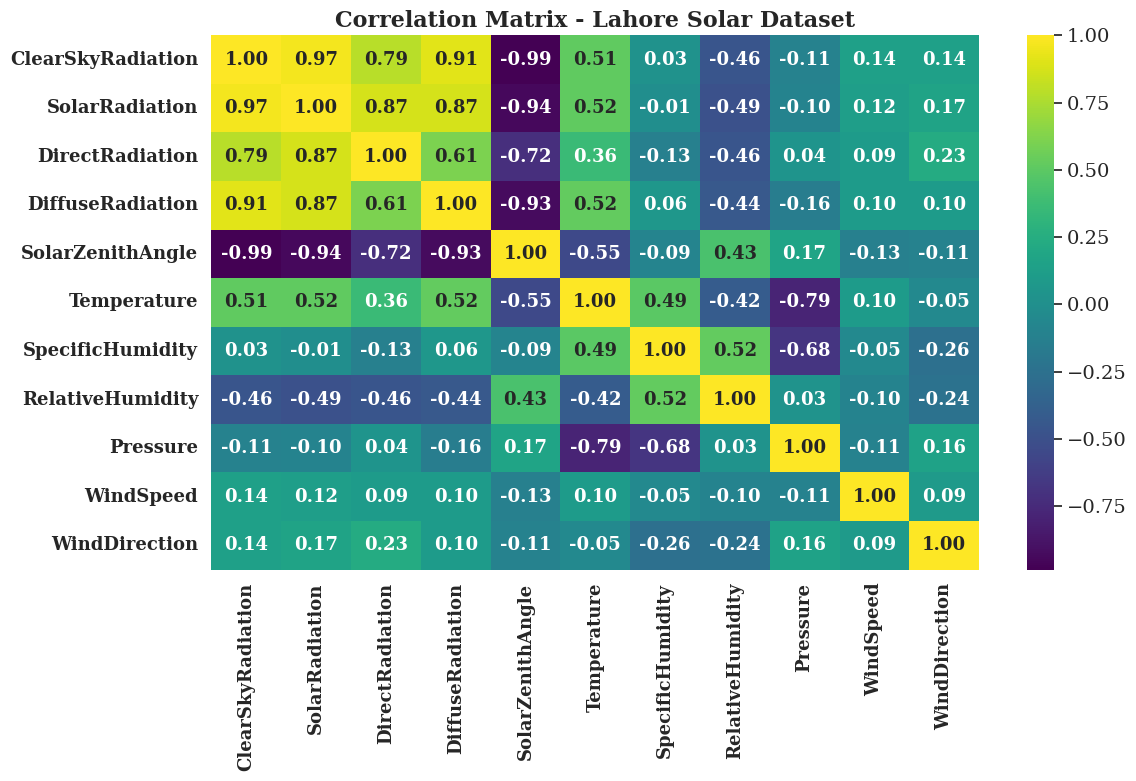

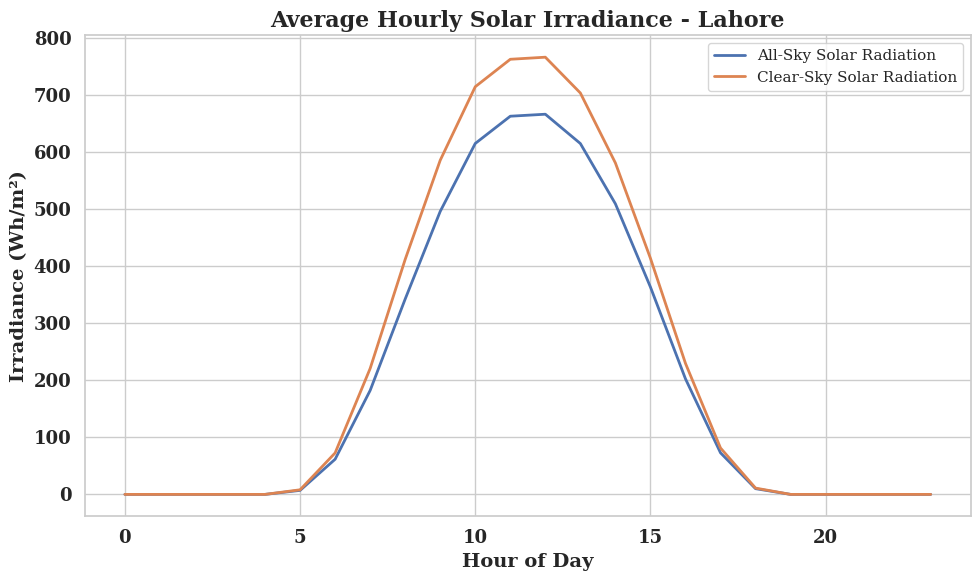


🌞 HOURLY SOLAR IRRADIANCE SUMMARY
Max All-Sky: 666.83 at hour 12
Max Clear-Sky: 766.85 at hour 12


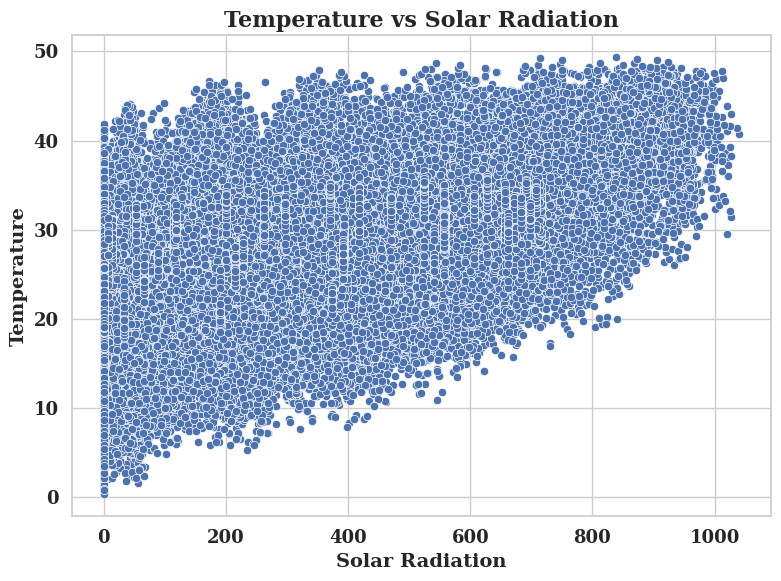

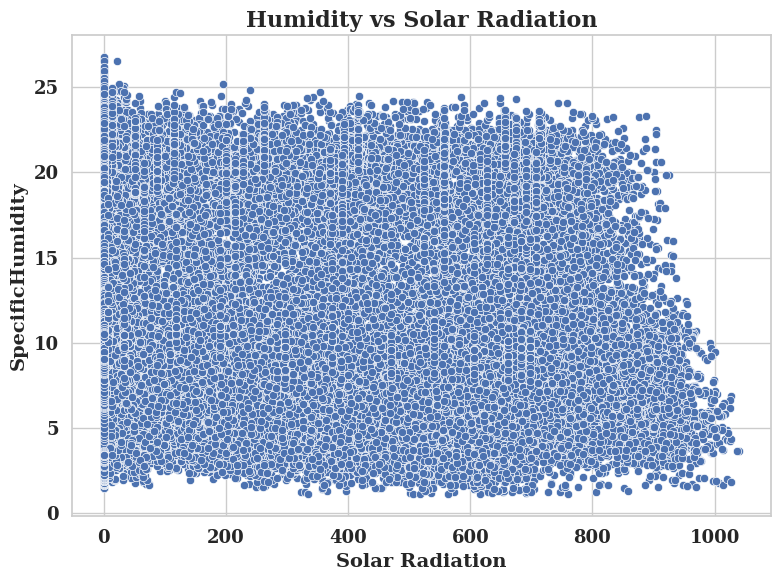

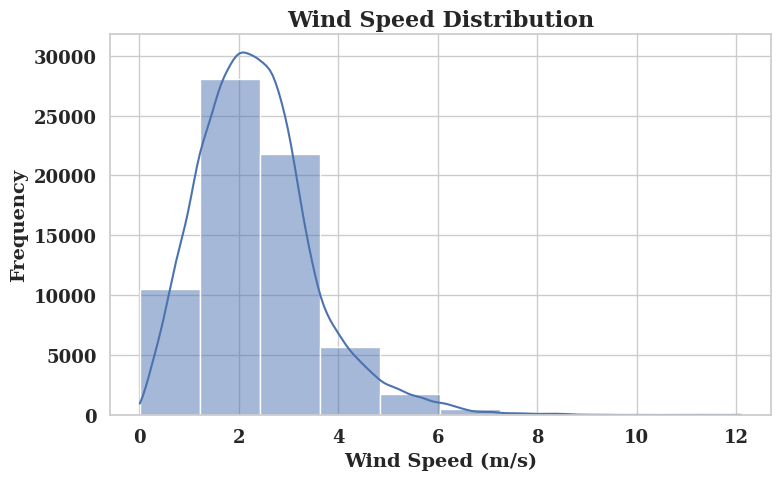

/tmp/ipykernel_3792/1150574885.py:248: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample('M').mean(numeric_only=True)


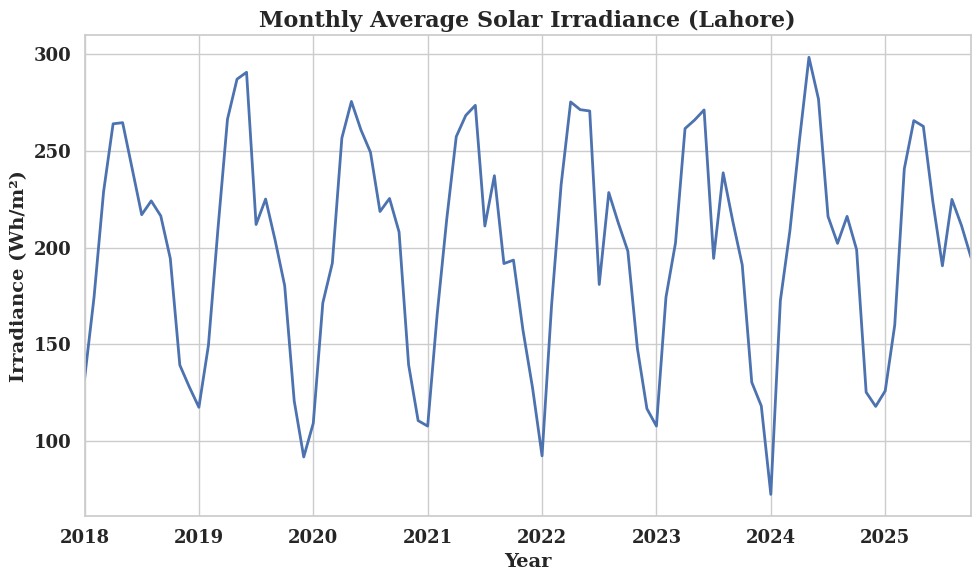


✅ Cleaned dataset saved successfully


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Global Plot Settings
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

annot_settings = {"fontsize": 13, "fontweight": "bold"}

# ==========================================================
# 🔥 Helper Function (FINAL VERSION)
# ==========================================================

def make_axis_bold(ax):
    # Axis labels (size 14)
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)

    # Tick labels (size 13)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(13)

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(13)


# ==========================================================
# 1️⃣ Load and Prepare Data
# ==========================================================

df = pd.read_csv('NASA-Lahore-Hourly-Data.csv')

df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M')
df.set_index('datetime', inplace=True)

df.replace(-999, np.nan, inplace=True)

# ==========================================================
# 📊 Missing Values Visualization
# ==========================================================

missing_counts = df.isna().sum()

plt.figure(figsize=(10,6))
ax = missing_counts.plot(kind='bar')

ax.set_title("Missing Values per Variable", fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Missing Values")
ax.set_xlabel("Variables")

plt.xticks(rotation=45, ha='right')

make_axis_bold(ax)

plt.tight_layout()
plt.show()

# Heatmap
plt.figure(figsize=(14,5))
ax = sns.heatmap(df.isna().T, cbar=False, cmap="viridis")

ax.set_title("Missing Data Timeline", fontsize=16, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Variables")

make_axis_bold(ax)

plt.tight_layout()
plt.show()

# ==========================================================
# 2️⃣ Handle Missing Data — Climatology Fill
# ==========================================================

print("\n🔍 Checking missing values before fill:")
print(df.isna().sum())

df['month'] = df.index.month
df['hour'] = df.index.hour

climatology = (
    df[df.index.year < 2025]
    .groupby(['month', 'hour'])
    .mean(numeric_only=True)
)

mask_missing = (df.index >= '2025-07-01') & (df.index < '2025-11-01')

def fill_with_climatology(row):
    if row.isna().any():
        m, h = row['month'], row['hour']
        if (m, h) in climatology.index:
            for col in climatology.columns:
                if pd.isna(row[col]):
                    row[col] = round(climatology.loc[(m, h), col], 2)
    return row

df.loc[mask_missing] = df.loc[mask_missing].apply(fill_with_climatology, axis=1)

print("\n✅ Missing values filled using climatology")

df.drop(columns=['month', 'hour'], inplace=True)

# ==========================================================
# 3️⃣ Descriptive Statistics
# ==========================================================

print("\n📊 Basic Descriptive Statistics:")
print(df.describe().T)

# ==========================================================
# 4️⃣ Correlation Heatmap
# ==========================================================

numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, ax = plt.subplots(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    annot_kws=annot_settings,
    ax=ax
)

ax.set_title("Correlation Matrix - Lahore Solar Dataset",
             fontsize=16, fontweight="bold")

make_axis_bold(ax)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ Hourly Solar Irradiance
# ==========================================================

hourly_avg = df.groupby(df.index.hour).mean(numeric_only=True)

plt.figure(figsize=(10,6))
ax = plt.gca()

ax.plot(hourly_avg.index, hourly_avg['SolarRadiation'],
        label='All-Sky Solar Radiation', linewidth=2)

ax.plot(hourly_avg.index, hourly_avg['ClearSkyRadiation'],
        label='Clear-Sky Solar Radiation', linewidth=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Irradiance (Wh/m²)')
ax.set_title('Average Hourly Solar Irradiance - Lahore',
             fontsize=16, fontweight="bold")

make_axis_bold(ax)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 📊 HOURLY NUMERICAL INSIGHTS
# ==========================================================

all_sky = hourly_avg['SolarRadiation']
clear_sky = hourly_avg['ClearSkyRadiation']

print("\n🌞 HOURLY SOLAR IRRADIANCE SUMMARY")

print(f"Max All-Sky: {all_sky.max():.2f} at hour {all_sky.idxmax()}")
print(f"Max Clear-Sky: {clear_sky.max():.2f} at hour {clear_sky.idxmax()}")

# ==========================================================
# 6️⃣ Temperature vs Solar Radiation
# ==========================================================

plt.figure(figsize=(8,6))
ax = sns.scatterplot(data=df, x='SolarRadiation', y='Temperature')

ax.set_title('Temperature vs Solar Radiation', fontsize=16, fontweight="bold")
ax.set_xlabel('Solar Radiation')
ax.set_ylabel('Temperature')

make_axis_bold(ax)

plt.tight_layout()
plt.show()

# ==========================================================
# 7️⃣ Humidity vs Solar Radiation (FIXED)
# ==========================================================

# Auto-detect humidity column
humidity_col = None
for col in df.columns:
    if "humid" in col.lower():
        humidity_col = col
        break

if humidity_col is None:
    print("⚠️ No humidity column found!")
else:
    plt.figure(figsize=(8,6))
    ax = sns.scatterplot(data=df, x='SolarRadiation', y=humidity_col)

    ax.set_title('Humidity vs Solar Radiation', fontsize=16, fontweight="bold")
    ax.set_xlabel('Solar Radiation')
    ax.set_ylabel(humidity_col)

    make_axis_bold(ax)

    plt.tight_layout()
    plt.show()

# ==========================================================
# 8️⃣ Wind Speed Distribution
# ==========================================================

plt.figure(figsize=(8,5))
ax = sns.histplot(df['WindSpeed'], bins=10, kde=True)

ax.set_title('Wind Speed Distribution', fontsize=16, fontweight="bold")
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Frequency')

make_axis_bold(ax)

plt.tight_layout()
plt.show()

# ==========================================================
# 9️⃣ Monthly Solar Trends
# ==========================================================

monthly_avg = df.resample('M').mean(numeric_only=True)

plt.figure(figsize=(10,6))
ax = plt.gca()

monthly_avg['SolarRadiation'].plot(linewidth=2, ax=ax)

ax.set_title('Monthly Average Solar Irradiance (Lahore)',
             fontsize=16, fontweight="bold")
ax.set_ylabel('Irradiance (Wh/m²)')
ax.set_xlabel('Year')

make_axis_bold(ax)

plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 🔟 Save Cleaned Data
# ==========================================================

df.to_csv('lahore_hourly_climatology_filled.csv')

print("\n✅ Cleaned dataset saved successfully")

In [ ]:
# ==========================================================
# 11️⃣ Extend Dataset by One Week Beyond Last Date
# ==========================================================

# Determine last datetime in the dataset
last_dt = df.index.max()
one_week_ahead = last_dt + pd.Timedelta(days=7)

# Create hourly datetime range for one extra week
extended_index = pd.date_range(start=last_dt + pd.Timedelta(hours=1), end=one_week_ahead, freq='H')

# Prepare empty DataFrame
extended_df = pd.DataFrame(index=extended_index)

# Extract month/hour for climatology mapping
extended_df['month'] = extended_df.index.month
extended_df['hour'] = extended_df.index.hour

# Fill extended data using climatology (2018–2024)
for col in climatology.columns:
    extended_df[col] = extended_df.apply(
        lambda row: round(climatology.loc[(row['month'], row['hour']), col], 2)
        if (row['month'], row['hour']) in climatology.index else np.nan, axis=1
    )

# Drop helper columns
extended_df.drop(columns=['month', 'hour'], inplace=True)

# Append to original dataset (optional)
df_extended = pd.concat([df, extended_df])

# Save extended data
extended_df.to_csv('one-week-extended-data.csv', index=True)
print("\n✅ One-week extended hourly dataset saved as 'one-week-extended-data.csv'")



✅ One-week extended hourly dataset saved as 'one-week-extended-data.csv'


**Average over all years to see typical monthly behavior. Useful to visualize seasons (summer peaks, winter lows).**

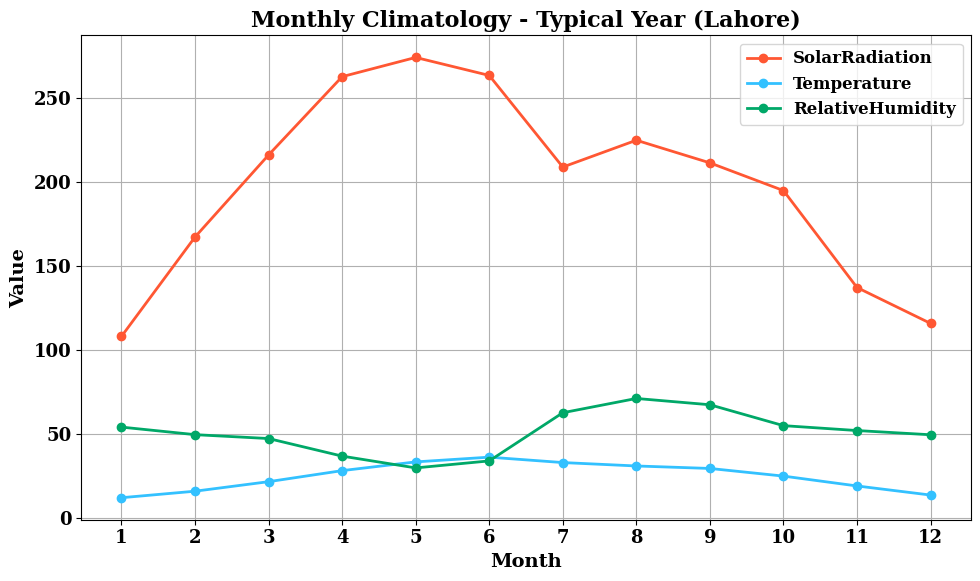

In [11]:
# ==========================================================
# Monthly Climatology - Typical Year (Lahore)
# ==========================================================

monthly_clim = df.groupby(df.index.month).mean(numeric_only=True)

plt.figure(figsize=(10,6))
ax = plt.gca()

# Define bright colors
colors = {
    'SolarRadiation': '#FF5733',
    'Temperature': '#33C1FF',
    'RelativeHumidity': '#00A868'
}

# Plot
monthly_clim[['SolarRadiation', 'Temperature', 'RelativeHumidity']].plot(
    marker='o',
    linewidth=2,
    color=[colors[col] for col in ['SolarRadiation', 'Temperature', 'RelativeHumidity']],
    ax=ax
)

# Title
ax.set_title("Monthly Climatology - Typical Year (Lahore)",
             fontsize=16, fontweight="bold")

# Axis labels
ax.set_xlabel("Month", fontsize=14, fontweight="bold")
ax.set_ylabel("Value", fontsize=14, fontweight="bold")

# Grid
ax.grid(True)

# X ticks (bold + size 13)
ax.set_xticks(monthly_clim.index)
ax.set_xticklabels([str(m) for m in monthly_clim.index],
                   fontsize=13, fontweight='bold')

# Y ticks (bold + size 13)
for label in ax.get_yticklabels():
    label.set_fontsize(13)
    label.set_fontweight('bold')

# Legend (bold)
legend = ax.legend(loc='upper right', fontsize=12)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# 📊 Monthly Climatology - Numerical Insights
# ==========================================================

monthly_clim = df.groupby(df.index.month).mean(numeric_only=True)

solar = monthly_clim['SolarRadiation']
temp = monthly_clim['Temperature']
humidity = monthly_clim['HumidityRelative']

print("\n📅 MONTHLY CLIMATOLOGY - NUMERICAL SUMMARY")

# ==========================================================
# 🌞 Solar Radiation
# ==========================================================
print("\n🌞 SOLAR RADIATION")
print(f"Peak Month: {solar.idxmax()} → {solar.max():.2f} Wh/m²")
print(f"Lowest Month: {solar.idxmin()} → {solar.min():.2f} Wh/m²")
print(f"Mean Value: {solar.mean():.2f} Wh/m²")

# ==========================================================
# 🌡️ Temperature
# ==========================================================
print("\n🌡️ TEMPERATURE")
print(f"Peak Month: {temp.idxmax()} → {temp.max():.2f} °C")
print(f"Lowest Month: {temp.idxmin()} → {temp.min():.2f} °C")
print(f"Mean Value: {temp.mean():.2f} °C")

# ==========================================================
# 💧 Humidity
# ==========================================================
print("\n💧 RELATIVE HUMIDITY")
print(f"Peak Month: {humidity.idxmax()} → {humidity.max():.2f} %")
print(f"Lowest Month: {humidity.idxmin()} → {humidity.min():.2f} %")
print(f"Mean Value: {humidity.mean():.2f} %")

# ==========================================================
# 📊 Additional Seasonal Insight (Important for paper)
# ==========================================================

print("\n📌 SEASONAL INTERPRETATION")

print(f"Solar Radiation Range: {solar.max() - solar.min():.2f} Wh/m²")
print(f"Temperature Range: {temp.max() - temp.min():.2f} °C")
print(f"Humidity Range: {humidity.max() - humidity.min():.2f} %")


📅 MONTHLY CLIMATOLOGY - NUMERICAL SUMMARY

🌞 SOLAR RADIATION
Peak Month: 5 → 274.30 Wh/m²
Lowest Month: 1 → 108.17 Wh/m²
Mean Value: 198.85 Wh/m²

🌡️ TEMPERATURE
Peak Month: 6 → 36.22 °C
Lowest Month: 1 → 12.07 °C
Mean Value: 24.88 °C

💧 RELATIVE HUMIDITY
Peak Month: 8 → 71.19 %
Lowest Month: 5 → 29.82 %
Mean Value: 50.81 %

📌 SEASONAL INTERPRETATION
Solar Radiation Range: 166.14 Wh/m²
Temperature Range: 24.15 °C
Humidity Range: 41.36 %


**See how the diurnal pattern changes month to month. Reveals sunrise/sunset shift and seasonal daylight variation.**

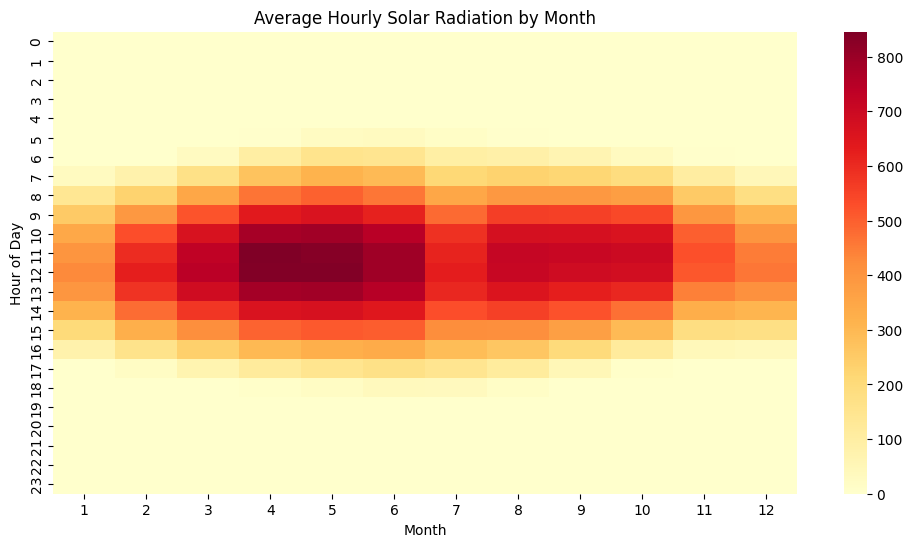

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.pivot_table(values='SolarRadiation',
                           index=df.index.hour,
                           columns=df.index.month,
                           aggfunc='mean'),
            cmap='YlOrRd')
plt.title('Average Hourly Solar Radiation by Month')
plt.xlabel('Month')
plt.ylabel('Hour of Day')
plt.show()


**Helps detect nonlinear relations or correlated predictors.**

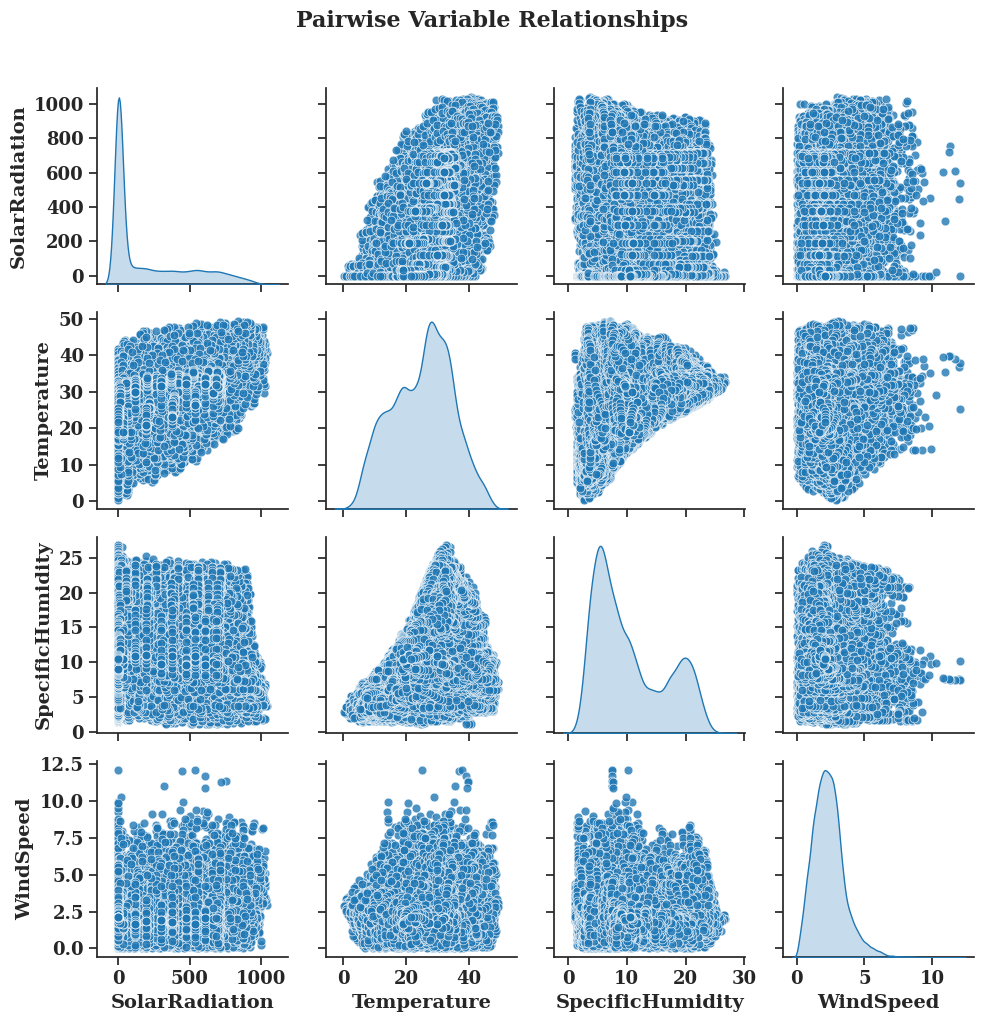

In [12]:
# ==========================================================
# Pairwise Variable Relationships - Styled
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Auto-detect humidity column
humidity_col = None
for col in df.columns:
    if "humid" in col.lower():
        humidity_col = col
        break

if humidity_col is None:
    raise ValueError("No humidity column found!")

# Variables to plot
vars_to_plot = ['SolarRadiation', 'Temperature', humidity_col, 'WindSpeed']

# Style
sns.set(style="ticks", font="serif")

# Create pairplot
pairplot = sns.pairplot(
    df[vars_to_plot],
    diag_kind='kde',
    plot_kws={'alpha':0.8, 's':40, 'color':'#1f77b4'},
    diag_kws={'fill':True, 'color':'#1f77b4'}
)

# ==========================================================
# 🔥 Apply FONT STYLING (IMPORTANT PART)
# ==========================================================

for ax in pairplot.axes.flatten():
    if ax is not None:
        # Axis labels (size 14 bold)
        ax.set_xlabel(ax.get_xlabel(), fontsize=14, fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize=14, fontweight='bold')

        # Tick labels (size 13 bold)
        for label in ax.get_xticklabels():
            label.set_fontsize(13)
            label.set_fontweight('bold')

        for label in ax.get_yticklabels():
            label.set_fontsize(13)
            label.set_fontweight('bold')

# Title
pairplot.fig.suptitle(
    "Pairwise Variable Relationships",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# 📊 Pairplot Numerical Statistical Insights
# ==========================================================

vars_to_plot = ['SolarRadiation', 'Temperature', 'HumidityRelative', 'WindSpeed']

print("\n📊 BASIC RANGE STATISTICS")

for col in vars_to_plot:
    print(f"\n{col}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")

# ==========================================================
# 📊 CORRELATION MATRIX (NUMERICAL r VALUES)
# ==========================================================

print("\n📌 PEARSON CORRELATION COEFFICIENTS")

corr = df[vars_to_plot].corr()

print(corr)

# Extract key relationships
print("\n🔍 KEY RELATIONSHIPS")

print(f"SolarRadiation vs Temperature: {corr.loc['SolarRadiation','Temperature']:.3f}")
print(f"SolarRadiation vs Humidity: {corr.loc['SolarRadiation','HumidityRelative']:.3f}")
print(f"SolarRadiation vs WindSpeed: {corr.loc['SolarRadiation','WindSpeed']:.3f}")

print(f"Temperature vs Humidity: {corr.loc['Temperature','HumidityRelative']:.3f}")
print(f"Temperature vs WindSpeed: {corr.loc['Temperature','WindSpeed']:.3f}")
print(f"Humidity vs WindSpeed: {corr.loc['HumidityRelative','WindSpeed']:.3f}")

# ==========================================================
# 📊 DISTRIBUTION SHAPE INDICATORS
# ==========================================================

print("\n📌 DISTRIBUTION SHAPE (SKEWNESS)")

print(df[vars_to_plot].skew())

print("\n📌 INTERPRETATION RULES")
print("- Skew > 1 → Highly right-skewed distribution")
print("- Skew between -1 and 1 → Approximately symmetric")
print("- Skew < -1 → Left-skewed distribution")

# ==========================================================
# 📊 EXTREME VALUE ANALYSIS (OUTLIERS)
# ==========================================================

print("\n📌 EXTREME VALUES (OUTLIER CHECK)")

for col in vars_to_plot:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    print(f"\n{col}")
    print(f"Lower Bound: {lower:.2f}, Upper Bound: {upper:.2f}")
    print(f"Number of Outliers: {len(outliers)}")


📊 BASIC RANGE STATISTICS

SolarRadiation
Min: 0.00
Max: 1040.18
Mean: 200.43
Std Dev: 275.38

Temperature
Min: 0.32
Max: 49.36
Mean: 25.10
Std Dev: 9.61

HumidityRelative
Min: 2.36
Max: 100.00
Mean: 50.84
Std Dev: 23.22

WindSpeed
Min: 0.01
Max: 12.10
Mean: 2.36
Std Dev: 1.17

📌 PEARSON CORRELATION COEFFICIENTS
                  SolarRadiation  Temperature  HumidityRelative  WindSpeed
SolarRadiation          1.000000     0.516588         -0.489672   0.117313
Temperature             0.516588     1.000000         -0.417025   0.095798
HumidityRelative       -0.489672    -0.417025          1.000000  -0.095748
WindSpeed               0.117313     0.095798         -0.095748   1.000000

🔍 KEY RELATIONSHIPS
SolarRadiation vs Temperature: 0.517
SolarRadiation vs Humidity: -0.490
SolarRadiation vs WindSpeed: 0.117
Temperature vs Humidity: -0.417
Temperature vs WindSpeed: 0.096
Humidity vs WindSpeed: -0.096

📌 DISTRIBUTION SHAPE (SKEWNESS)
SolarRadiation      1.132034
Temperature        -0.13897

**Analyze wind direction/speed distributions. Reveals dominant wind direction patterns.**

/tmp/ipykernel_3792/3509900886.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


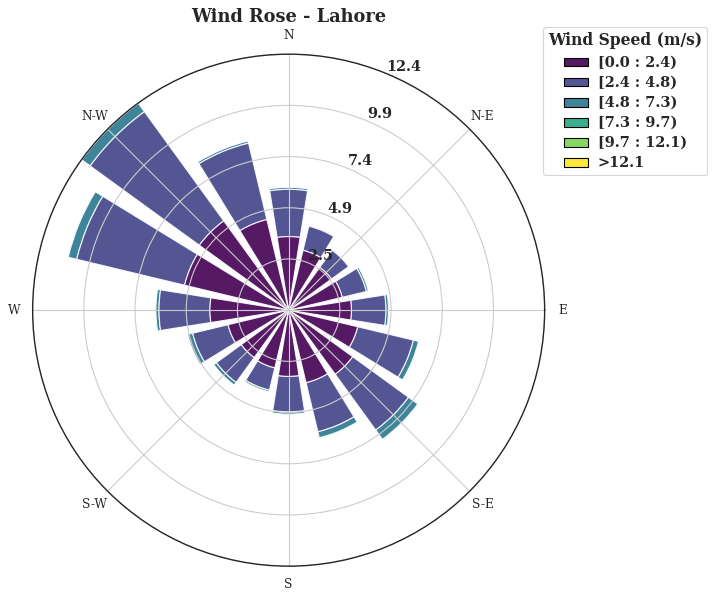

In [23]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Global font
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

# Create Windrose
ax = WindroseAxes.from_ax()

ax.bar(
    df['WindDirection'],
    df['WindSpeed'],
    normed=True,
    opening=0.8,
    edgecolor='white',
    alpha=0.9,
    cmap=plt.cm.viridis
)

# Title
ax.set_title("Wind Rose - Lahore", fontsize=16, fontweight='bold', y=1.05)

# ==========================================================
# 🔥 BOLD INNER CIRCLE NUMBERS (RADIAL TICKS)
# ==========================================================

for label in ax.get_yticklabels():
    label.set_fontsize(13)
    label.set_fontweight('bold')

# ==========================================================
# 🔥 Legend (OUTSIDE + STYLED)
# ==========================================================

legend = ax.set_legend(
    title="Wind Speed (m/s)",
    loc='upper left',
    bbox_to_anchor=(1.0, 1.05),
)

legend.get_title().set_fontsize(14)
legend.get_title().set_fontweight('bold')

for text in legend.get_texts():
    text.set_fontsize(13)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# 🌬️ Wind Rose - Numerical Insights (Lahore)
# ==========================================================

print("\n🌬️ WIND ROSE - NUMERICAL ANALYSIS")

# ==========================================================
# 1️⃣ Wind Speed Statistics
# ==========================================================

print("\n📊 WIND SPEED STATISTICS")

print(f"Min Wind Speed: {df['WindSpeed'].min():.2f} m/s")
print(f"Max Wind Speed: {df['WindSpeed'].max():.2f} m/s")
print(f"Mean Wind Speed: {df['WindSpeed'].mean():.2f} m/s")
print(f"Median Wind Speed: {df['WindSpeed'].median():.2f} m/s")
print(f"Std Dev: {df['WindSpeed'].std():.2f} m/s")

# ==========================================================
# 2️⃣ Wind Direction Statistics
# ==========================================================

print("\n🧭 WIND DIRECTION STATISTICS")

print(f"Min Direction: {df['WindDirection'].min():.2f}°")
print(f"Max Direction: {df['WindDirection'].max():.2f}°")
print(f"Mean Direction: {df['WindDirection'].mean():.2f}°")

# Most frequent direction (dominant wind direction)
dominant_dir = df['WindDirection'].mode()[0]
print(f"Dominant Wind Direction: {dominant_dir:.2f}°")

# ==========================================================
# 3️⃣ Wind Direction Sector Analysis
# ==========================================================

print("\n📌 WIND DIRECTION SECTORS")

# Convert degrees into meteorological sectors
def direction_sector(deg):
    if 0 <= deg < 45 or 315 <= deg <= 360:
        return "N / NE"
    elif 45 <= deg < 135:
        return "E"
    elif 135 <= deg < 225:
        return "S"
    else:
        return "W"

df['WindSector'] = df['WindDirection'].apply(direction_sector)

sector_counts = df['WindSector'].value_counts(normalize=True) * 100

print("\nWind Sector Percentage Distribution:")
print(sector_counts)

# ==========================================================
# 4️⃣ Wind Speed Classes (Important for Wind Rose interpretation)
# ==========================================================

print("\n🌪️ WIND SPEED CLASS DISTRIBUTION")

bins = [0, 2, 4, 6, 8, 10, 20]
labels = ["0–2 (Calm)", "2–4 (Light)", "4–6 (Moderate)",
          "6–8 (Fresh)", "8–10 (Strong)", "10+ (Very Strong)"]

df['WindClass'] = pd.cut(df['WindSpeed'], bins=bins, labels=labels)

class_dist = df['WindClass'].value_counts(normalize=True) * 100

print(class_dist)

# ==========================================================
# 5️⃣ Extreme Wind Events
# ==========================================================

print("\n⚠️ EXTREME WIND EVENTS ANALYSIS")

q1 = df['WindSpeed'].quantile(0.25)
q3 = df['WindSpeed'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

extreme_winds = df[df['WindSpeed'] > upper_bound]

print(f"Upper Threshold for Extreme Wind: {upper_bound:.2f} m/s")
print(f"Number of Extreme Wind Events: {len(extreme_winds)}")
print(f"Percentage of Extreme Events: {len(extreme_winds)/len(df)*100:.2f}%")


🌬️ WIND ROSE - NUMERICAL ANALYSIS

📊 WIND SPEED STATISTICS
Min Wind Speed: 0.01 m/s
Max Wind Speed: 12.10 m/s
Mean Wind Speed: 2.36 m/s
Median Wind Speed: 2.25 m/s
Std Dev: 1.17 m/s

🧭 WIND DIRECTION STATISTICS
Min Direction: 0.00°
Max Direction: 359.80°
Mean Direction: 205.30°
Dominant Wind Direction: 270.00°

📌 WIND DIRECTION SECTORS

Wind Sector Percentage Distribution:
WindSector
W         31.352267
N / NE    26.170231
S         21.549205
E         20.928296
Name: proportion, dtype: float64

🌪️ WIND SPEED CLASS DISTRIBUTION
WindClass
2–4 (Light)          50.737786
0–2 (Calm)           41.029687
4–6 (Moderate)        7.234689
6–8 (Fresh)           0.879500
8–10 (Strong)         0.105189
10+ (Very Strong)     0.013149
Name: proportion, dtype: float64

⚠️ EXTREME WIND EVENTS ANALYSIS
Upper Threshold for Extreme Wind: 5.12 m/s
Number of Extreme Wind Events: 1840
Percentage of Extreme Events: 2.69%


**Rolling Statistics (Moving Average): Identify slow-changing trends over time. Highlights long-term smoothing and anomalies.**

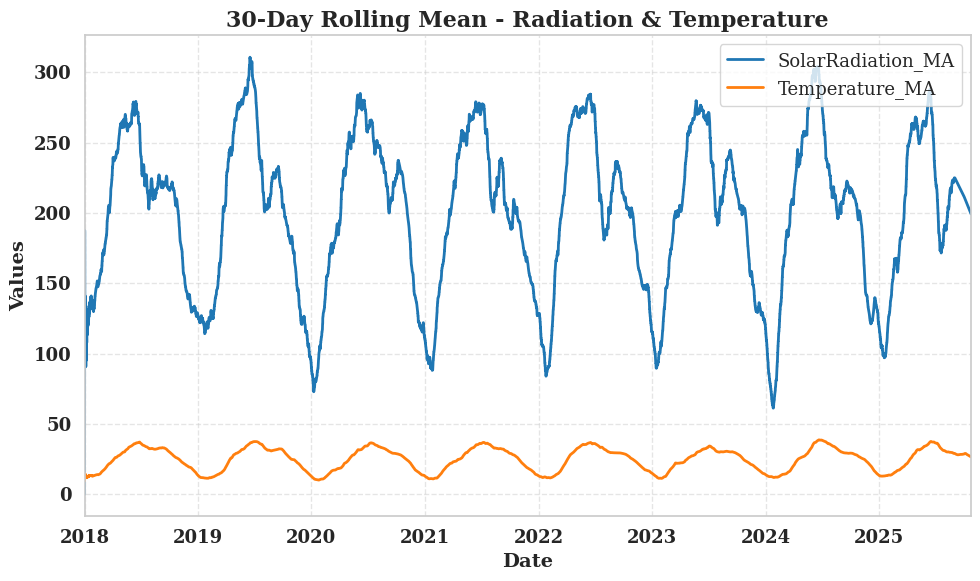

In [43]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

# ==========================================================
# Rolling Means
# ==========================================================

df['SolarRadiation_MA'] = df['SolarRadiation'].rolling('30D').mean()
df['Temperature_MA'] = df['Temperature'].rolling('30D').mean()

# Plot
ax = df[['SolarRadiation_MA', 'Temperature_MA']].plot(
    figsize=(10,6),
    color=['#1f77b4', '#ff7f0e'],
    linewidth=2,
    ax=None
)

# ==========================================================
# Title (16 bold)
# ==========================================================
ax.set_title('30-Day Rolling Mean - Radiation & Temperature',
             fontsize=16, fontweight='bold')

# ==========================================================
# Axis labels (14 bold)
# ==========================================================
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Values', fontsize=14, fontweight='bold')

# ==========================================================
# Tick labels (13 bold)
# ==========================================================
for label in ax.get_xticklabels():
    label.set_fontsize(13)
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontsize(13)
    label.set_fontweight('bold')

# ==========================================================
# Grid
# ==========================================================
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(
    loc='upper right',
    fontsize=13
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# 📊 30-Day Rolling Mean - Numerical Insights
# ==========================================================

print("\n📈 30-DAY ROLLING MEAN ANALYSIS")

# ==========================================================
# 1️⃣ Smoothed Solar Radiation Statistics
# ==========================================================

solar_ma = df['SolarRadiation_MA'].dropna()
temp_ma = df['Temperature_MA'].dropna()

print("\n🌞 SOLAR RADIATION (30-day Moving Average)")

print(f"Max Smoothed Value: {solar_ma.max():.2f}")
print(f"Min Smoothed Value: {solar_ma.min():.2f}")
print(f"Mean Smoothed Value: {solar_ma.mean():.2f}")

print(f"Peak Date: {solar_ma.idxmax().date()}")
print(f"Lowest Date: {solar_ma.idxmin().date()}")

# ==========================================================
# 2️⃣ Smoothed Temperature Statistics
# ==========================================================

print("\n🌡️ TEMPERATURE (30-day Moving Average)")

print(f"Max Smoothed Value: {temp_ma.max():.2f}")
print(f"Min Smoothed Value: {temp_ma.min():.2f}")
print(f"Mean Smoothed Value: {temp_ma.mean():.2f}")

print(f"Peak Date: {temp_ma.idxmax().date()}")
print(f"Lowest Date: {temp_ma.idxmin().date()}")

# ==========================================================
# 3️⃣ Relationship Between Smoothed Variables
# ==========================================================

print("\n📌 SMOOTHED CORRELATION (Trend-Level Relationship)")

trend_corr = df[['SolarRadiation_MA', 'Temperature_MA']].corr().iloc[0,1]

print(f"Correlation (30-day trend): {trend_corr:.3f}")

# ==========================================================
# 4️⃣ Variability Reduction Analysis
# ==========================================================

print("\n📉 VARIABILITY REDUCTION (Smoothing Effect)")

solar_std_raw = df['SolarRadiation'].std()
solar_std_ma = solar_ma.std()

temp_std_raw = df['Temperature'].std()
temp_std_ma = temp_ma.std()

print(f"Solar Radiation Std Reduction: {solar_std_raw - solar_std_ma:.2f}")
print(f"Temperature Std Reduction: {temp_std_raw - temp_std_ma:.2f}")

print("\n👉 Interpretation:")
print("- Rolling mean removes short-term fluctuations")
print("- Highlights seasonal/climatic trend")
print("- Improves signal-to-noise ratio")

# ==========================================================
# 5️⃣ Seasonal Trend Insight
# ==========================================================

print("\n📌 SEASONAL TREND INSIGHT")

solar_range = solar_ma.max() - solar_ma.min()
temp_range = temp_ma.max() - temp_ma.min()

print(f"Solar Trend Range: {solar_range:.2f}")
print(f"Temperature Trend Range: {temp_range:.2f}")



📈 30-DAY ROLLING MEAN ANALYSIS

🌞 SOLAR RADIATION (30-day Moving Average)
Max Smoothed Value: 310.86
Min Smoothed Value: 0.00
Mean Smoothed Value: 200.02
Peak Date: 2019-06-17
Lowest Date: 2018-01-01

🌡️ TEMPERATURE (30-day Moving Average)
Max Smoothed Value: 38.78
Min Smoothed Value: 9.59
Mean Smoothed Value: 25.03
Peak Date: 2024-06-21
Lowest Date: 2018-01-01

📌 SMOOTHED CORRELATION (Trend-Level Relationship)
Correlation (30-day trend): 0.866

📉 VARIABILITY REDUCTION (Smoothing Effect)
Solar Radiation Std Reduction: 219.73
Temperature Std Reduction: 1.51

👉 Interpretation:
- Rolling mean removes short-term fluctuations
- Highlights seasonal/climatic trend
- Improves signal-to-noise ratio

📌 SEASONAL TREND INSIGHT
Solar Trend Range: 310.86
Temperature Trend Range: 29.19


**Check Stationarity (for Time Series): Helps decide if differencing or detrending is needed.**


1.   No significant long-term upward or downward trend.
2.   Mean and variance are stable over time.
3.   Perfectly suitable for time-series models (like ARIMA, SARIMAX, Prophet, or LSTM) without differencing.

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['SolarRadiation'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -14.305422432342818
p-value: 1.2091220799700876e-26


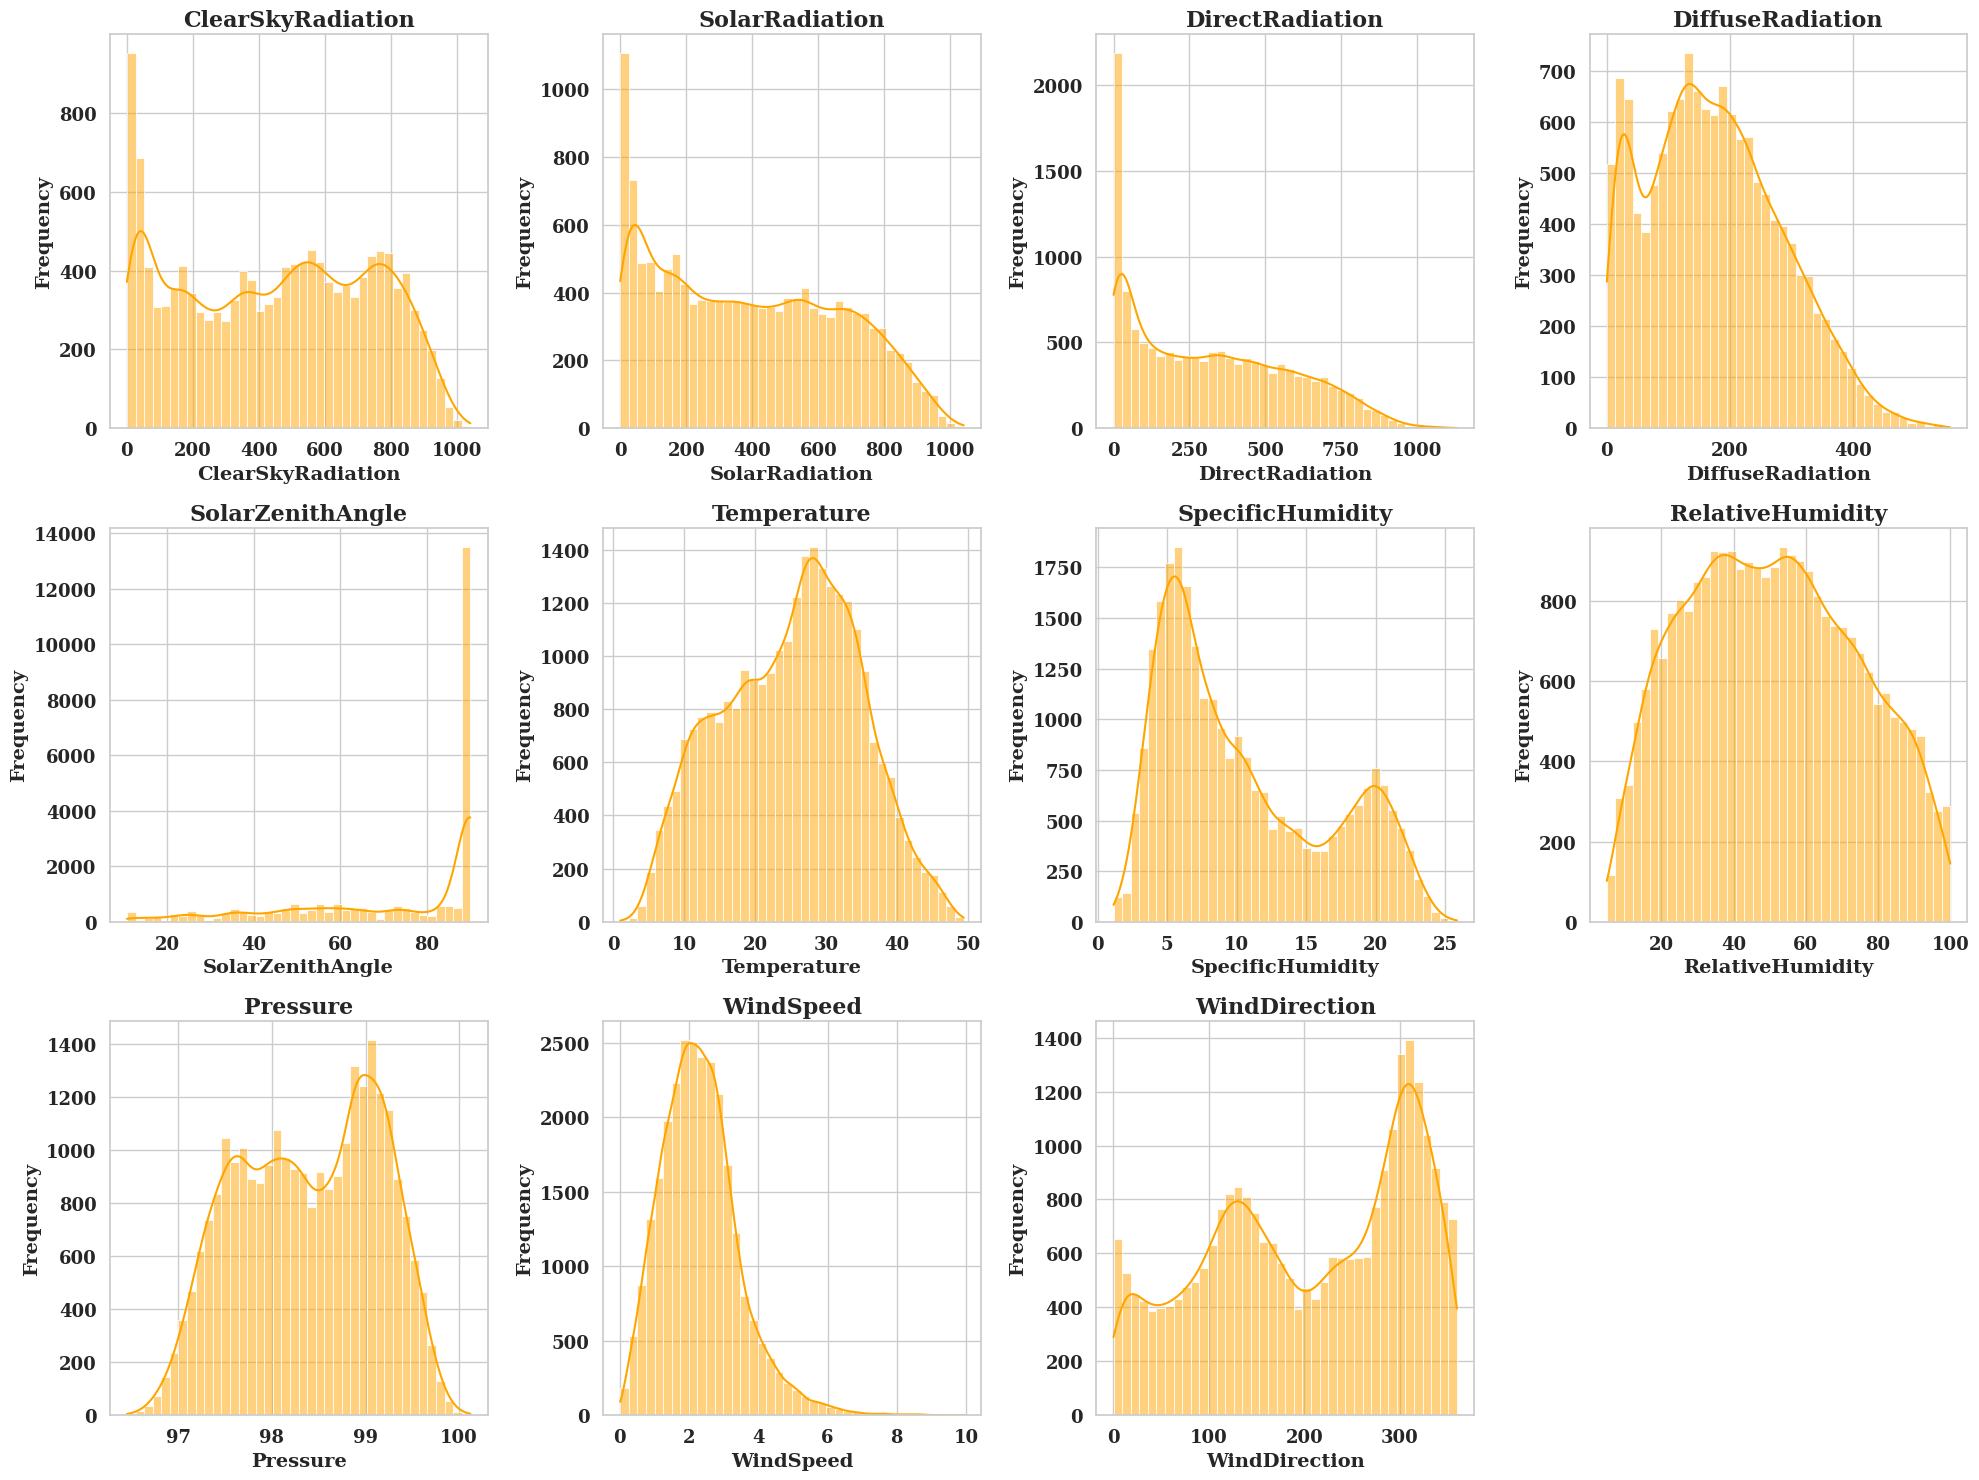


✅ All feature distributions plotted (4 per row).


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# =========================================
# GLOBAL STYLE (SERIF)
# =========================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13
})

sns.set_style("whitegrid")

# =========================================
# Load Dataset
# =========================================

file_path = "lahore_hourly_filled.csv"
df = pd.read_csv(file_path)

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime")

df = df.replace(0, np.nan)

# =========================================
# Numeric Columns
# =========================================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

n_cols_grid = 4   # 🔥 FIX: 4 plots per row
n_rows = math.ceil(len(numeric_cols) / n_cols_grid)

# =========================================
# Create Figure
# =========================================

fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(20, 5*n_rows))
axes = axes.flatten()

# =========================================
# Plot Histograms
# =========================================

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        color="orange",
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=16, fontweight="bold", fontfamily="serif")
    axes[i].set_xlabel(col, fontsize=14, fontweight="bold", fontfamily="serif")
    axes[i].set_ylabel("Frequency", fontsize=14, fontweight="bold", fontfamily="serif")

    # Tick styling
    for label in axes[i].get_xticklabels():
        label.set_fontsize(13)
        label.set_fontweight("bold")
        label.set_fontfamily("serif")

    for label in axes[i].get_yticklabels():
        label.set_fontsize(13)
        label.set_fontweight("bold")
        label.set_fontfamily("serif")

# =========================================
# Hide empty plots
# =========================================

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("\n✅ All feature distributions plotted (4 per row).")

In [ ]:
# ==========================================================
# 📊 ALL FEATURE DISTRIBUTION - NUMERICAL ANALYSIS
# ==========================================================

print("\n📊 FEATURE DISTRIBUTION STATISTICS")

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    print(f"\n==================== {col} ====================")

    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")

    # Skewness
    skew = df[col].skew()
    print(f"Skewness: {skew:.3f}")

    # Kurtosis
    kurt = df[col].kurtosis()
    print(f"Kurtosis: {kurt:.3f}")

    # IQR outlier detection
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    print(f"Outliers Count: {len(outliers)}")

    # Distribution interpretation
    print("\n📌 Interpretation:")

    if abs(skew) < 0.5:
        print("- Approximately symmetric distribution")
    elif skew > 0.5:
        print("- Right-skewed (positive skew, long tail on right)")
    else:
        print("- Left-skewed (negative skew, long tail on left)")

    if kurt > 3:
        print("- Heavy-tailed distribution (high peak, extreme values present)")
    else:
        print("- Light/moderate tails (closer to normal distribution)")


📊 FEATURE DISTRIBUTION STATISTICS

==================== ClearSkyRadiation ====================
Min: 2.58
Max: 1040.38
Mean: 452.88
Median: 464.33
Std Dev: 288.12
Skewness: -0.010
Kurtosis: -1.245
Outliers Count: 0

📌 Interpretation:
- Approximately symmetric distribution
- Light/moderate tails (closer to normal distribution)

==================== SolarRadiation ====================
Min: 2.45
Max: 1040.18
Mean: 395.89
Median: 374.66
Std Dev: 275.35
Skewness: 0.257
Kurtosis: -1.111
Outliers Count: 0

📌 Interpretation:
- Approximately symmetric distribution
- Light/moderate tails (closer to normal distribution)

==================== DirectRadiation ====================
Min: 0.09
Max: 1033.87
Mean: 305.42
Median: 259.32
Std Dev: 257.31
Skewness: 0.566
Kurtosis: -0.762
Outliers Count: 0

📌 Interpretation:
- Right-skewed (positive skew, long tail on right)
- Light/moderate tails (closer to normal distribution)

==================== DiffuseRadiation ====================
Min: 3.00
Max: 557.57

## **Modelling Hourly Forecasting**

In [ ]:
# ==========================================
# 🌤 Benchmark: XGBoost, RandomForest, LSTM, CNN-LSTM
# Save Models + Remove Transformer
# ==========================================

import os, gc, warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# create save directory
os.makedirs("saved_models", exist_ok=True)

# TF GPU memory growth (Colab safe)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

# ---------- 1. Load data ----------
df = pd.read_csv('lahore_hourly_filled.csv')
df.columns = df.columns.str.strip()

if 'datetime' not in df.columns:
    raise ValueError(f"'datetime' column not found")

df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()

df = df.apply(pd.to_numeric, errors='coerce')

print("Loaded CSV range:", df.index.min(), "→", df.index.max())

required = ['ClearSkyRadiation','SolarRadiation','DirectRadiation','DiffuseRadiation',
            'SolarZenith','Temperature','HumiditySpecific','HumidityRelative',
            'Pressure','WindSpeed','WindDirection']

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError("Missing columns: ", missing)

df_day = df[df['SolarZenith'] < 90].copy()
df_day.dropna(subset=['SolarRadiation'], inplace=True)
df_day['hour'] = df_day.index.hour
df_day['month'] = df_day.index.month

target_col = 'SolarRadiation'
print("Daylight records:", len(df_day))

# ---------- 2. Train/Test split ----------
split_idx = int(len(df_day) * 0.8)
train = df_day.iloc[:split_idx].copy()
test  = df_day.iloc[split_idx:].copy()

# ---------- 3. Lag features ----------
MAX_LAG = 24

def make_lag_features(series_df, max_lag=24):
    cols_base = [target_col,'hour','month','Temperature','HumiditySpecific',
                 'HumidityRelative','Pressure','WindSpeed','WindDirection']
    df_feat = series_df[cols_base].copy()
    for lag in range(1, max_lag+1):
        df_feat[f"lag_{lag}"] = df_feat[target_col].shift(lag)
    return df_feat.dropna()

df_lag = make_lag_features(df_day, MAX_LAG)

train_lag = df_lag.loc[df_lag.index.intersection(train.index)]
test_lag  = df_lag.loc[df_lag.index.intersection(test.index)]

# fallback if no test rows
if len(test_lag) == 0:
    train_lag = df_lag.iloc[:-MAX_LAG].copy()
    test_lag  = df_lag.iloc[-MAX_LAG:].copy()

X_train_tree = train_lag.drop(columns=[target_col])
y_train_tree = train_lag[target_col]
X_test_tree  = test_lag.drop(columns=[target_col])
y_test       = test_lag[target_col]

# ---------- 4. Scaling for deep learning ----------
SEQ_LEN = 24
features = ['hour','month','Temperature','HumiditySpecific','HumidityRelative',
            'Pressure','WindSpeed','WindDirection', target_col]
df_seq = df_day[features].dropna()

train_seq_df = df_seq.loc[:train.index.max()]
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train_seq_df.drop(columns=[target_col]))
scaler_y.fit(train_seq_df[[target_col]])

# Save scalers
joblib.dump(scaler_X, "saved_models/scaler_X.pkl")
joblib.dump(scaler_y, "saved_models/scaler_y.pkl")

def create_sequences(df_in, seq_len=24):
    Xs, ys, idxs = [], [], []
    X_arr = scaler_X.transform(df_in.drop(columns=[target_col]))
    y_arr = scaler_y.transform(df_in[[target_col]]).flatten()

    for i in range(seq_len, len(df_in)):
        Xs.append(X_arr[i-seq_len:i])
        ys.append(y_arr[i])
        idxs.append(df_in.index[i])

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq_all, y_seq_all, idxs_all = create_sequences(df_seq)

train_idx_set = set(train.index)
test_idx_set  = set(test.index)

train_mask = np.array([idx in train_idx_set for idx in idxs_all])
test_mask  = np.array([idx in test_idx_set  for idx in idxs_all])

X_train_seq = X_seq_all[train_mask]
y_train_seq = y_seq_all[train_mask]
X_test_seq  = X_seq_all[test_mask]
y_test_seq  = y_seq_all[test_mask]

y_train_unscaled = scaler_y.inverse_transform(y_train_seq.reshape(-1,1)).flatten()
y_test_unscaled  = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

# ---------- RESULTS ----------
results = []

# ======================================
# 6. XGBoost
# ======================================
print("\n=== Training XGBoost ===")
xgb_model = xgb.XGBRegressor(
    n_estimators=800, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_model.fit(X_train_tree, y_train_tree)

# Save model
joblib.dump(xgb_model, "saved_models/xgboost_model.pkl")

xgb_train_pred = xgb_model.predict(X_train_tree)
xgb_test_pred  = xgb_model.predict(X_test_tree)

results.append([
    'XGBoost',
    r2_score(y_train_tree, xgb_train_pred),
    r2_score(y_test, xgb_test_pred),
    mean_absolute_error(y_test, xgb_test_pred),
    rmse(y_test, xgb_test_pred)
])

# ======================================
# 7. Random Forest
# ======================================
print("\n=== Training Random Forest ===")
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_tree, y_train_tree)

# Save model
joblib.dump(rf, "saved_models/random_forest_model.pkl")

rf_train_pred = rf.predict(X_train_tree)
rf_test_pred  = rf.predict(X_test_tree)

results.append([
    'Random Forest',
    r2_score(y_train_tree, rf_train_pred),
    r2_score(y_test, rf_test_pred),
    mean_absolute_error(y_test, rf_test_pred),
    rmse(y_test, rf_test_pred)
])

# ======================================
# 8. LSTM
# ======================================
print("\n=== Training LSTM ===")
K.clear_session()
lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

es = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=0
)

# Save model
lstm_model.save("saved_models/lstm_model.h5")

lstm_train_pred = scaler_y.inverse_transform(lstm_model.predict(X_train_seq))
lstm_test_pred  = scaler_y.inverse_transform(lstm_model.predict(X_test_seq))

lstm_train_pred = lstm_train_pred.flatten()
lstm_test_pred  = lstm_test_pred.flatten()

results.append([
    'LSTM',
    r2_score(y_train_unscaled, lstm_train_pred),
    r2_score(y_test_unscaled, lstm_test_pred),
    mean_absolute_error(y_test_unscaled, lstm_test_pred),
    rmse(y_test_unscaled, lstm_test_pred)
])

# ======================================
# 9. CNN-LSTM
# ======================================
print("\n=== Training CNN-LSTM ===")
K.clear_session()
inp = layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2]))
x = layers.Conv1D(32, 3, padding='same', activation='relu')(inp)
x = layers.MaxPool1D(2)(x)
x = layers.LSTM(48)(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(24, activation='relu')(x)
out = layers.Dense(1)(x)

cnn_lstm_model = models.Model(inp, out)
cnn_lstm_model.compile(optimizer='adam', loss='mse')

cnn_lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=0
)

# Save model
cnn_lstm_model.save("saved_models/cnn_lstm_model.h5")

cnn_train_pred = scaler_y.inverse_transform(cnn_lstm_model.predict(X_train_seq))
cnn_test_pred  = scaler_y.inverse_transform(cnn_lstm_model.predict(X_test_seq))

cnn_train_pred = cnn_train_pred.flatten()
cnn_test_pred  = cnn_test_pred.flatten()

results.append([
    'CNN-LSTM',
    r2_score(y_train_unscaled, cnn_train_pred),
    r2_score(y_test_unscaled, cnn_test_pred),
    mean_absolute_error(y_test_unscaled, cnn_test_pred),
    rmse(y_test_unscaled, cnn_test_pred)
])

# ---------- 10. Final Results ----------
results_df = pd.DataFrame(results, columns=['Model','R2_Train','R2_Test','MAE_Test','RMSE_Test'])
print(results_df)
results_df.to_csv("saved_models/model_results.csv", index=False)

print("\n🎉 All models saved successfully in: saved_models/")



Loaded CSV range: 2018-01-01 00:00:00 → 2025-12-10 23:00:00
Daylight records: 13912

=== Training XGBoost ===

=== Training Random Forest ===

=== Training LSTM ===


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== Training CNN-LSTM ===


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
           Model  R2_Train   R2_Test   MAE_Test   RMSE_Test
0        XGBoost  0.995255  0.984802  21.148956   33.411270
1  Random Forest  0.993038  0.984101  21.914068   34.173322
2           LSTM  0.876743  0.846722  77.816966  106.107268
3       CNN-LSTM  0.883269  0.841865  77.835346  107.775190

🎉 All models saved successfully in: saved_models/


**Next 7 Day Forecast Beyond Data**

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb

# ---------- 1. Load data ----------
df = pd.read_csv('lahore_hourly_filled.csv', parse_dates=['datetime'], index_col='datetime')
df = df.sort_index().apply(pd.to_numeric, errors='coerce')

# daylight-only filter (for training)
df_day = df[df['SolarZenith'] < 90].copy()
df_day.dropna(subset=['SolarRadiation'], inplace=True)
df_day['hour'] = df_day.index.hour
df_day['month'] = df_day.index.month

target_col = 'SolarRadiation'

# ---------- 2. Lag features ----------
MAX_LAG = 24
def make_lag_features(series_df, max_lag=24):
    df_feat = series_df[[target_col,'hour','month','Temperature','HumiditySpecific',
                         'HumidityRelative','Pressure','WindSpeed','WindDirection']].copy()
    for lag in range(1, max_lag+1):
        df_feat[f"lag_{lag}"] = df_feat[target_col].shift(lag)
    return df_feat.dropna()

df_lag = make_lag_features(df_day, MAX_LAG)
X_train = df_lag.drop(columns=[target_col])
y_train = df_lag[target_col]

# ---------- 3. Train XGBoost ----------
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=2, verbosity=0
)
xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained.")

# ---------- 4. Forecast next 7 days (daylight hours only, 12h/day) ----------
last_time = df_day.index.max()
forecast_days = 7
daylight_hours = range(6, 18)  # 6 AM to 5 PM (12 hours)
forecast_results = []

forecast_input = df_day.iloc[-MAX_LAG:].copy()
expected_columns = forecast_input.columns.tolist()

for day in range(forecast_days):
    for hr in daylight_hours:
        # Create feature row
        row_data = {
            'hour': hr,
            'month': (last_time + pd.Timedelta(days=day)).month,
            'Temperature': forecast_input['Temperature'].iloc[-1],
            'HumiditySpecific': forecast_input['HumiditySpecific'].iloc[-1],
            'HumidityRelative': forecast_input['HumidityRelative'].iloc[-1],
            'Pressure': forecast_input['Pressure'].iloc[-1],
            'WindSpeed': forecast_input['WindSpeed'].iloc[-1],
            'WindDirection': forecast_input['WindDirection'].iloc[-1],
        }
        for lag in range(1, MAX_LAG+1):
            row_data[f'lag_{lag}'] = forecast_input['SolarRadiation'].iloc[-lag]

        X_pred = pd.DataFrame([row_data])
        X_pred = X_pred.reindex(columns=X_train.columns, fill_value=np.nan)
        y_pred = xgb_model.predict(X_pred)[0]
        forecast_results.append({
            'datetime': last_time + pd.Timedelta(days=day, hours=hr),
            'SolarRadiation_Forecast': y_pred
        })

        # Append prediction to forecast_input for next lag calculation
        new_row = {col: np.nan for col in expected_columns}
        new_row['SolarRadiation'] = y_pred
        new_row['hour'] = hr
        new_row['month'] = row_data['month']
        new_row['Temperature'] = row_data['Temperature']
        new_row['HumiditySpecific'] = row_data['HumiditySpecific']
        new_row['HumidityRelative'] = row_data['HumidityRelative']
        new_row['Pressure'] = row_data['Pressure']
        new_row['WindSpeed'] = row_data['WindSpeed']
        new_row['WindDirection'] = row_data['WindDirection']
        new_row_df = pd.DataFrame([new_row], index=[last_time + pd.Timedelta(days=day, hours=hr)])
        forecast_input = pd.concat([forecast_input, new_row_df])

# ---------- 5. Save forecast ----------
forecast_df = pd.DataFrame(forecast_results)
forecast_df.set_index('datetime', inplace=True)
forecast_df.to_csv('xgboost_7day_daylight_forecast.csv')
print("✅ 7-day daylight-only forecast saved to xgboost_7day_daylight_forecast.csv")
print(forecast_df.head(24))  # first 12-hour daylight of day 1


✅ XGBoost trained.
✅ 7-day daylight-only forecast saved to xgboost_7day_daylight_forecast.csv
                     SolarRadiation_Forecast
datetime                                    
2025-10-22 23:00:00                37.059315
2025-10-23 00:00:00               199.914749
2025-10-23 01:00:00               391.624847
2025-10-23 02:00:00               568.055664
2025-10-23 03:00:00               677.752686
2025-10-23 04:00:00               696.070190
2025-10-23 05:00:00               671.796875
2025-10-23 06:00:00               594.722168
2025-10-23 07:00:00               460.763702
2025-10-23 08:00:00               283.236847
2025-10-23 09:00:00               117.083389
2025-10-23 10:00:00                12.396963
2025-10-23 23:00:00                44.576225
2025-10-24 00:00:00               197.593567
2025-10-24 01:00:00               380.266602
2025-10-24 02:00:00               541.592407
2025-10-24 03:00:00               653.201416
2025-10-24 04:00:00               675.377319
2025-1

R2: 0.998, MAE: 6.64, RMSE: 11.80


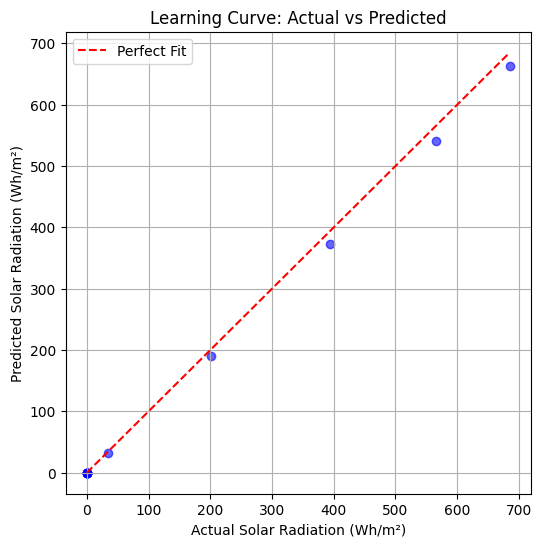

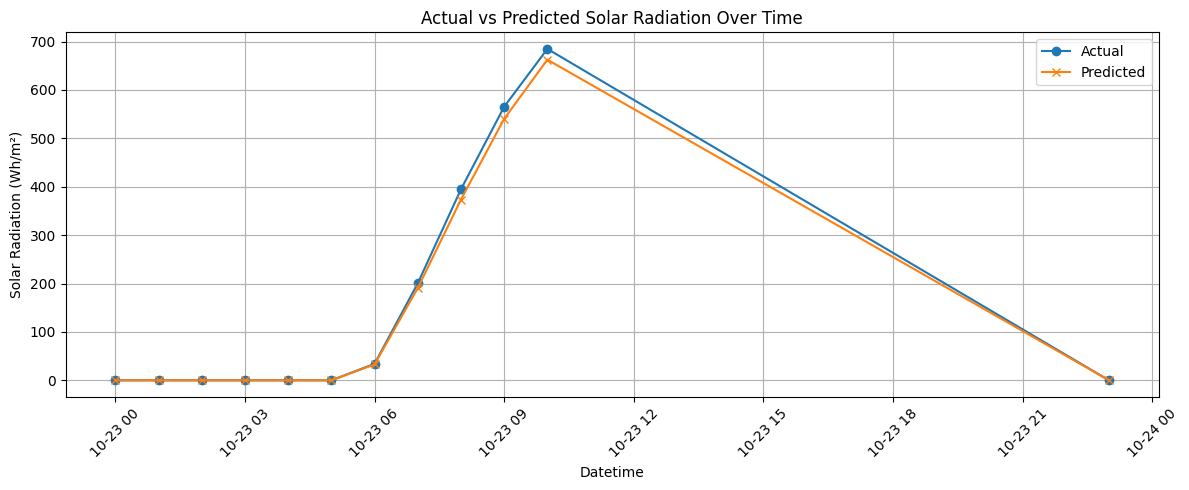

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# -------------------------------
# 1️⃣ Hardcoded XGBoost 7-day daylight forecast
# -------------------------------
data_xgb = {
    'datetime': [
        '2025-10-22 23:00:00','2025-10-23 00:00:00','2025-10-23 01:00:00','2025-10-23 02:00:00',
        '2025-10-23 03:00:00','2025-10-23 04:00:00','2025-10-23 05:00:00','2025-10-23 06:00:00',
        '2025-10-23 07:00:00','2025-10-23 08:00:00','2025-10-23 09:00:00','2025-10-23 10:00:00',
        '2025-10-23 23:00:00','2025-10-24 00:00:00','2025-10-24 01:00:00','2025-10-24 02:00:00',
        '2025-10-24 03:00:00','2025-10-24 04:00:00','2025-10-24 05:00:00','2025-10-24 06:00:00',
        '2025-10-24 07:00:00','2025-10-24 08:00:00','2025-10-24 09:00:00','2025-10-24 10:00:00'
    ],
    'SolarRadiation_Forecast': [
        37.059315,199.914749,391.624847,568.055664,677.752686,696.070190,671.796875,594.722168,
        460.763702,283.236847,117.083389,12.396963,44.576225,197.593567,380.266602,541.592407,
        653.201416,675.377319,646.658569,582.914124,453.450195,283.444031,113.446884,15.146305
    ]
}

df_pred = pd.DataFrame(data_xgb)
df_pred['datetime'] = pd.to_datetime(df_pred['datetime'])
df_pred.set_index('datetime', inplace=True)

# -------------------------------
# 2️⃣ Load actual daylight data
# -------------------------------
actual = pd.read_csv('one-week-extended-data.csv', index_col=0, parse_dates=True)
actual = actual.iloc[:24]  # Take same 12-hour cycle/daylight period for comparison

# -------------------------------
# 3️⃣ Align data
# -------------------------------
df_compare = actual.join(df_pred, how='inner')
df_compare.rename(columns={df_compare.columns[0]:'Actual', df_compare.columns[1]:'Predicted'}, inplace=True)

# -------------------------------
# 4️⃣ Compute Metrics
# -------------------------------
r2 = r2_score(df_compare['Actual'], df_compare['Predicted'])
mae = mean_absolute_error(df_compare['Actual'], df_compare['Predicted'])
rmse = np.sqrt(mean_squared_error(df_compare['Actual'], df_compare['Predicted']))

print(f"R2: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# -------------------------------
# 5️⃣ Scatter Plot: Actual vs Predicted
# -------------------------------
plt.figure(figsize=(6,6))
plt.scatter(df_compare['Actual'], df_compare['Predicted'], color='blue', alpha=0.6)
plt.plot([df_compare['Actual'].min(), df_compare['Actual'].max()],
         [df_compare['Actual'].min(), df_compare['Actual'].max()],
         color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Solar Radiation (Wh/m²)')
plt.ylabel('Predicted Solar Radiation (Wh/m²)')
plt.title('Learning Curve: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 6️⃣ Line Plot: Actual vs Predicted Over Time
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_compare.index, df_compare['Actual'], label='Actual', marker='o')
plt.plot(df_compare.index, df_compare['Predicted'], label='Predicted', marker='x')
plt.xlabel('Datetime')
plt.ylabel('Solar Radiation (Wh/m²)')
plt.title('Actual vs Predicted Solar Radiation Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
